# Project 1: Supply Chain Demand and Risk
## Notebook 2: Model selection, evaluation, and risk flags


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid
import joblib

plt.rcParams['figure.figsize'] = (10, 4)

## 1. Load the feature table from the previous notebook

In [2]:
df = pd.read_csv("project1_features.csv")
df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
df.head()

Shape: (4551, 16)


,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,is_new_sku,sold_lag_1,sold_lag_7,sold_roll_mean_7,sold_roll_mean_14,sold_roll_mean_7_prev,demand_trend,day_of_week,days_of_cover
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,False,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7,False,110.0,NaN,NaN,NaN,NaN,NaN,4,NaN
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7,False,278.0,NaN,NaN,NaN,NaN,NaN,5,NaN
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7,False,121.0,NaN,NaN,NaN,NaN,NaN,6,NaN
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7,False,75.0,NaN,NaN,NaN,NaN,NaN,0,NaN


## 2. Separate established SKUs from new SKUs

Established SKUs have enough history for the lag and rolling features to be valid, so they go through the forecasting model. New SKUs are handled with a simpler rule later in this notebook.

In [3]:
established = df[df["is_new_sku"] == False].copy()
new_sku_data = df[df["is_new_sku"] == True].copy()

print("Established SKU rows:", len(established))
print("New SKU rows:", len(new_sku_data))

Established SKU rows: 4515
New SKU rows: 36


## 3. Drop rows where features are not available yet

The lag and rolling features need at least 14 days of prior history to be calculated, so the first two weeks of each SKU's data have missing values in those columns. Those rows cannot be used for training or evaluation, so we remove them here.

In [4]:
feature_cols = ["sold_lag_1", "sold_lag_7", "sold_roll_mean_7", "sold_roll_mean_14", "demand_trend", "day_of_week"]

before = len(established)
established = established.dropna(subset=feature_cols + ["units_sold"])
after = len(established)

print(f"Dropped {before - after} rows with incomplete features, {after} rows remain")

Dropped 350 rows with incomplete features, 4165 rows remain


## 4. Split into training and test data by time, not randomly

A random split would put some days from June into training and some days from June into testing, which means the model could train on data from right before the exact day it is being tested on. That makes the evaluation look better than it really is, because in real use the model never has access to future data when making a prediction.

Instead we pick a cutoff date. Everything before it is training data, the model only ever sees the past. Everything after it is test data, a true simulation of predicting demand it has never seen. We use the final 30 days as the test period, and this cutoff stays fixed for every model and comparison in this notebook, so all of them are judged on the exact same unseen data.

In [5]:
cutoff_date = established["date"].max() - pd.Timedelta(days=30)

train = established[established["date"] <= cutoff_date]
test = established[established["date"] > cutoff_date]

X_train, y_train = train[feature_cols], train["units_sold"]
X_test, y_test = test[feature_cols], test["units_sold"]

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Training rows: {len(train)}  (from {train["date"].min().date()} to {train["date"].max().date()})")
print(f"Test rows: {len(test)}  (from {test["date"].min().date()} to {test["date"].max().date()})")

Cutoff date: 2026-05-30
Training rows: 3413  (from 2026-01-14 to 2026-05-30)
Test rows: 752  (from 2026-05-31 to 2026-06-29)


## 5. Establish a baseline before trying any model

Before reaching for machine learning, it is worth checking what a plain, no-model rule would score. If a trained model cannot beat a simple rule, the model is not earning its added complexity, and that is something worth knowing rather than hiding. The baseline used here is naive but reasonable, predict tomorrow's demand as the SKU's own 7-day rolling average, the same number already sitting in the feature table.

In [6]:
baseline_predictions = test["sold_roll_mean_7"]

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_mape = mean_absolute_percentage_error(y_test, baseline_predictions)

print(f"Baseline MAE: {baseline_mae:.1f} units")
print(f"Baseline MAPE: {baseline_mape * 100:.1f} percent")

Baseline MAE: 63.2 units
Baseline MAPE: 24.5 percent


## 6. Compare candidate models against the baseline

Three models are trained on the exact same training data and scored on the exact same held-out test period, so the comparison is fair. They range from simple to more complex, which is worth being able to explain, more complexity is only worth it if it actually earns a better score.


In [7]:
candidates = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = []
for name, candidate_model in candidates.items():
    candidate_model.fit(X_train, y_train)
    preds = candidate_model.predict(X_test)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "MAPE": mean_absolute_percentage_error(y_test, preds) * 100,
    })

results.append({"model": "Baseline (7-day average)", "MAE": baseline_mae, "MAPE": baseline_mape * 100})

comparison = pd.DataFrame(results).sort_values("MAE")
comparison

,model,MAE,MAPE
2,Gradient Boosting,55.589945,21.558169
0,Linear Regression,56.588967,22.458725
1,Random Forest,58.419973,22.472104
3,Baseline (7-day average),63.155585,24.464003


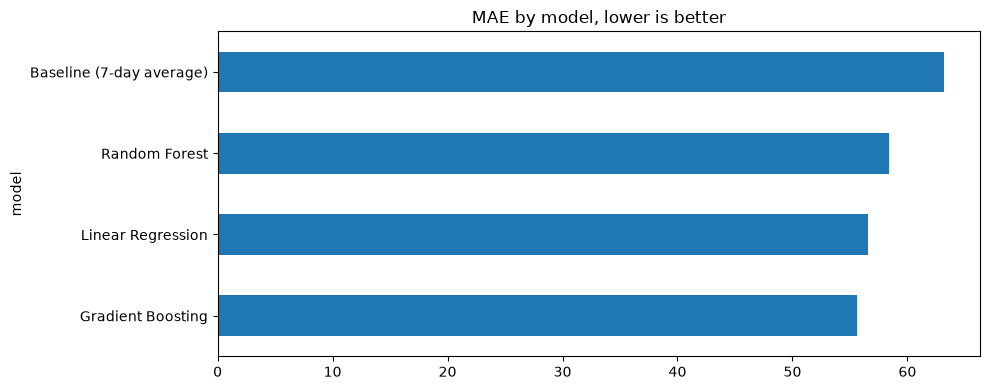

In [8]:
comparison.set_index("model")["MAE"].sort_values().plot(kind="barh", title="MAE by model, lower is better")
plt.tight_layout()
plt.show()

The best-scoring model here becomes the one we tune and carry forward. This choice is data-driven, not a default pick, and the table above is the evidence for it in the walkthrough.

In [9]:
best_model_name = comparison.iloc[0]["model"]
print(f"Best performing model: {best_model_name}")

Best performing model: Gradient Boosting


## 7. Light hyperparameter tuning on the best candidate

Default settings are a reasonable starting point but rarely the best one. Rather than an exhaustive search, which would cost more time than this assessment allows, a small, sensible grid is tried here.

To keep this honest, the test set is still not touched during tuning. A separate validation window, the 30 days before the test period, is carved out of the training data. Each candidate setting is trained on the remaining training data and scored on that validation window. Only after the best setting is chosen does it get retrained on the full training data and finally scored on the untouched test set.

In [10]:
val_cutoff = cutoff_date - pd.Timedelta(days=30)

tune_train = train[train["date"] <= val_cutoff]
val = train[train["date"] > val_cutoff]

X_tune_train, y_tune_train = tune_train[feature_cols], tune_train["units_sold"]
X_val, y_val = val[feature_cols], val["units_sold"]

print(f"Tuning training rows: {len(tune_train)}")
print(f"Validation rows: {len(val)}  (from {val["date"].min().date()} to {val["date"].max().date()})")

Tuning training rows: 2661
Validation rows: 752  (from 2026-05-01 to 2026-05-30)


In [11]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1],
}

tuning_results = []
for params in ParameterGrid(param_grid):
    candidate = GradientBoostingRegressor(random_state=42, **params)
    candidate.fit(X_tune_train, y_tune_train)
    val_preds = candidate.predict(X_val)
    tuning_results.append({**params, "val_MAE": mean_absolute_error(y_val, val_preds)})

tuning_df = pd.DataFrame(tuning_results).sort_values("val_MAE")
tuning_df.head(10)

,learning_rate,max_depth,n_estimators,val_MAE
2,0.05,3,100,55.964426
8,0.10,3,100,56.363415
1,0.05,2,200,56.506446
6,0.10,2,100,56.604060
3,0.05,3,200,56.714136
0,0.05,2,100,57.091361
7,0.10,2,200,57.135923
4,0.05,4,100,57.139318
9,0.10,3,200,57.808790
5,0.05,4,200,58.253583


In [12]:
best_params = tuning_df.iloc[0][["n_estimators", "max_depth", "learning_rate"]].to_dict()
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])

print("Best hyperparameters found on the validation window:")
print(best_params)

Best hyperparameters found on the validation window:
{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


## 8. Train the final model and evaluate it on the untouched test set

The chosen hyperparameters are now used to train on the full training period, then scored once on the test period that has not been touched since section 4.

In [13]:
model = GradientBoostingRegressor(random_state=42, **best_params)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)

print(f"Final tuned model, MAE: {mae:.1f} units")
print(f"Final tuned model, MAPE: {mape * 100:.1f} percent")
print(f"Baseline for comparison, MAE: {baseline_mae:.1f} units, MAPE: {baseline_mape * 100:.1f} percent")

Final tuned model, MAE: 55.2 units
Final tuned model, MAPE: 21.7 percent
Baseline for comparison, MAE: 63.2 units, MAPE: 24.5 percent


### Check for overfitting or underfitting

The test score alone does not tell the whole story. Comparing it against the training score shows whether the model learned a real, generalizable pattern, or just memorized the training data.

- If training error is much lower than test error, the model overfit, it performs well on data it has already seen and worse on new data.
- If both training and test error are high and close together, the model underfit, it did not learn much of a usable pattern at all.
- Training and test error being reasonably close, and both low, is the sign of a model that generalizes.

In [14]:
train_predictions = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_predictions)
train_mape = mean_absolute_percentage_error(y_train, train_predictions)

fit_check = pd.DataFrame([
    {"set": "Training", "MAE": train_mae, "MAPE": train_mape * 100},
    {"set": "Test", "MAE": mae, "MAPE": mape * 100},
])
fit_check

,set,MAE,MAPE
0,Training,50.959102,19.690587
1,Test,55.173880,21.665913


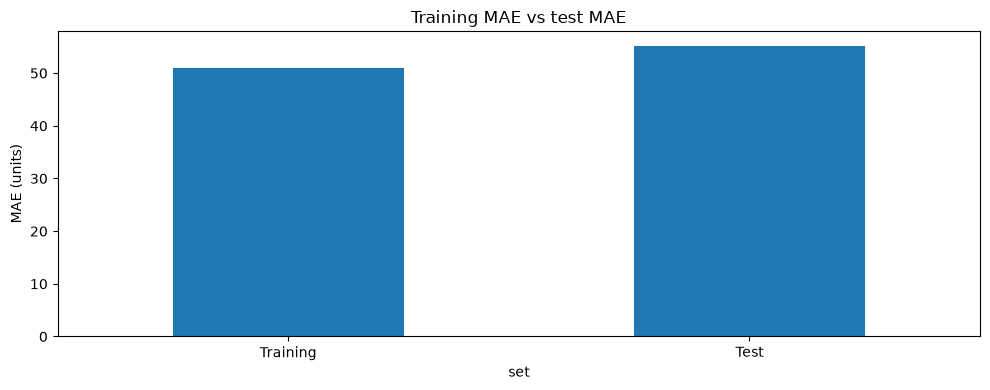

In [15]:
fit_check.set_index("set")["MAE"].plot(kind="bar", title="Training MAE vs test MAE")
plt.ylabel("MAE (units)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Actual demand versus predicted demand for one SKU, on the test period

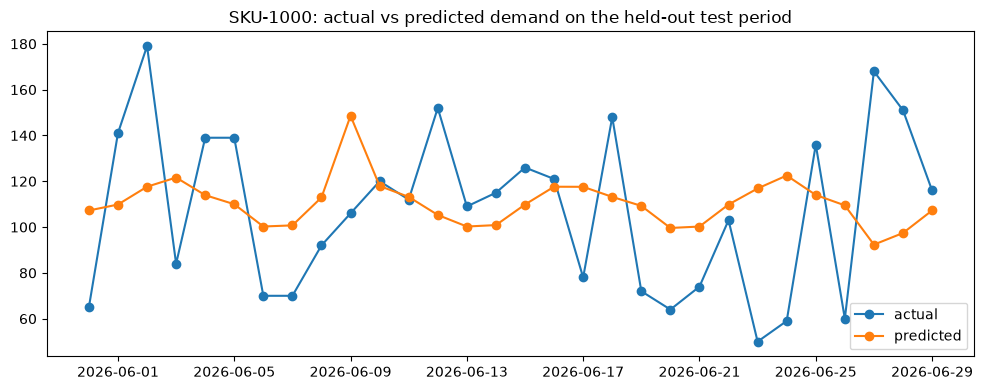

In [16]:
test_with_preds = test.copy()
test_with_preds["predicted"] = predictions

sample_sku = "SKU-1000"
sample = test_with_preds[test_with_preds["sku_id"] == sample_sku].sort_values("date")

plt.plot(sample["date"], sample["units_sold"], label="actual", marker="o")
plt.plot(sample["date"], sample["predicted"], label="predicted", marker="o")
plt.legend()
plt.title(f"{sample_sku}: actual vs predicted demand on the held-out test period")
plt.tight_layout()
plt.show()

### What is actually driving the model's predictions

This is a sanity check on the model itself, and it is also exactly what gets passed to the LLM later to generate the plain-English explanation for each flag.

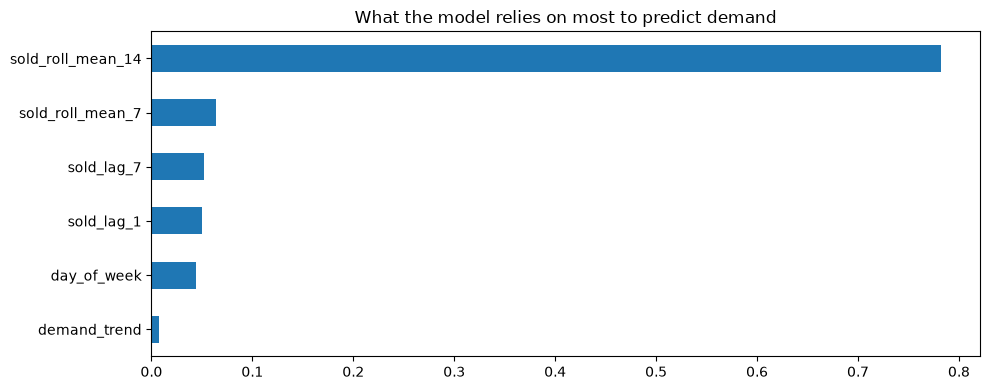

In [17]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", title="What the model relies on most to predict demand")
plt.tight_layout()
plt.show()

## 9. Turn forecasts into risk flags for established SKUs

For each established SKU, we take its most recent data, forecast next-day demand with the final model, then compute days of cover, current stock divided by forecasted daily demand. Comparing that to the SKU's lead time gives the actual flag.

- If days of cover is less than the lead time, the SKU is at risk of running out before a new order can arrive. This is a stockout risk.
- If days of cover is more than three times the lead time, and recent demand trend is flat or falling, there is too much stock sitting idle for how little is selling. This is an overstock risk.
- Anything else is not flagged.

In [18]:
latest = established.sort_values("date").groupby("sku_id").tail(1).copy()

latest["forecasted_demand"] = model.predict(latest[feature_cols])
latest["days_of_cover"] = latest["closing_stock"] / latest["forecasted_demand"].replace(0, np.nan)

def flag_risk(row):
    if row["days_of_cover"] < row["lead_time_days"]:
        return "stockout risk"
    if row["days_of_cover"] > 3 * row["lead_time_days"] and row["demand_trend"] <= 0:
        return "overstock risk"
    return "ok"

latest["risk_flag"] = latest.apply(flag_risk, axis=1)

latest["risk_flag"].value_counts()

risk_flag
ok               15
stockout risk    10
Name: count, dtype: int64

In [19]:
latest[["sku_id", "category", "closing_stock", "forecasted_demand", "days_of_cover", "lead_time_days", "demand_trend", "risk_flag"]].sort_values("risk_flag")

,sku_id,category,closing_stock,forecasted_demand,days_of_cover,lead_time_days,demand_trend,risk_flag
1807,SKU-1009,Beverages,9874.0,347.395141,28.422965,14,-23.285714,ok
2349,SKU-1012,Beverages,10771.0,410.868517,26.215199,14,-11.571429,ok
2890,SKU-1015,Pasta,2957.0,413.929490,7.143729,7,14.285714,ok
3251,SKU-1017,Beverages,1691.0,307.537981,5.498508,3,3.857143,ok
3071,SKU-1016,Snacks,4620.0,254.401819,18.160247,14,43.285714,ok
1266,SKU-1006,Sugar,10779.0,466.632182,23.099564,10,49.428571,ok
1085,SKU-1005,Pasta,1303.0,104.935558,12.417145,10,-22.000000,ok
2167,SKU-1011,Sugar,3373.0,195.351459,17.266316,14,15.571429,ok
903,SKU-1004,Beverages,2895.0,197.135802,14.685308,7,17.714286,ok
3612,SKU-1019,Snacks,8732.0,599.289253,14.570593,14,-19.714286,ok


## 10. Handle the 3 new SKUs with a simpler rule

These SKUs only have about 12 days of history, not enough to trust lag or rolling features built on a single-digit number of prior days, and not enough for a held-out test period either. Building a forecasting model on this little data would not be honest, the model would be fitting noise, not a real pattern.

Instead we use their plain average daily sales over the days available, and apply the same days-of-cover logic directly, without a model in between. These are marked clearly as early-stage estimates in the app, since the underlying data is thin.

In [20]:
new_sku_summary = new_sku_data.groupby("sku_id").agg(
    avg_daily_sales=("units_sold", "mean"),
    latest_stock=("closing_stock", "last"),
    lead_time_days=("lead_time_days", "last"),
    category=("category", "last"),
    days_of_history=("date", "count"),
).reset_index()

new_sku_summary["days_of_cover"] = new_sku_summary["latest_stock"] / new_sku_summary["avg_daily_sales"].replace(0, np.nan)

new_sku_summary["risk_flag"] = np.where(
    new_sku_summary["days_of_cover"] < new_sku_summary["lead_time_days"],
    "stockout risk (early estimate)",
    "ok (early estimate)"
)

new_sku_summary

,sku_id,avg_daily_sales,latest_stock,lead_time_days,category,days_of_history,days_of_cover,risk_flag
0,SKU-2000,220.083333,0.0,7,Snacks,12,0.0,stockout risk (early estimate)
1,SKU-2001,283.250000,0.0,10,Beverages,12,0.0,stockout risk (early estimate)
2,SKU-2002,268.083333,0.0,5,Flour,12,0.0,stockout risk (early estimate)


## 11. Save the model and the flag tables

The trained model, the model comparison table, and both flag tables are saved here so the Streamlit app can load them directly, without retraining anything at runtime, and so the comparison table can be referenced directly in the README and the slide deck.

In [21]:
joblib.dump(model, "demand_forecast_model.joblib")

comparison.to_csv("model_comparison.csv", index=False)
latest.to_csv("established_sku_flags.csv", index=False)
new_sku_summary.to_csv("new_sku_flags.csv", index=False)

print("Saved: demand_forecast_model.joblib, model_comparison.csv, established_sku_flags.csv, new_sku_flags.csv")

Saved: demand_forecast_model.joblib, model_comparison.csv, established_sku_flags.csv, new_sku_flags.csv
